# <div align="center"><u>The low variance dataset</u>

## - General description of the low variance dataset:
    
The following implementation applies a low variance filter to the Colon-Kidney dataset, where the dimensionality ranges between 55 and 110 features (gene expressions).

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold

import time

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the final colon-kidney dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv")

# Print the dataset
df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1,Colon


### Compute the variance of each feature

In [5]:
# Compute the variance of each feature
variance_series = df.iloc[:, :-2].var()  # Exclude last 2 columns ('Target' and 'Tissue')

### Plot the variance of each feature

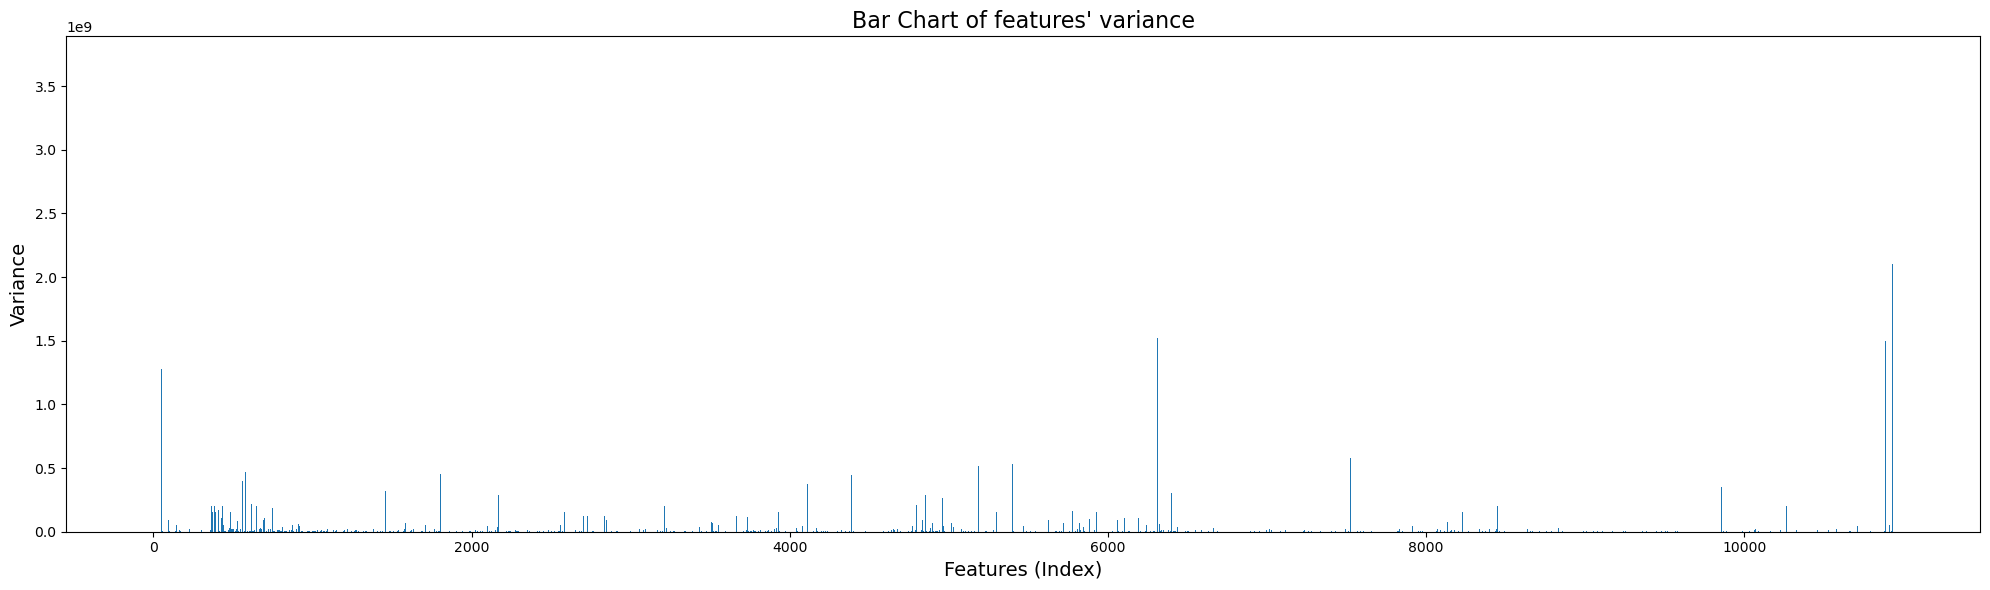

In [6]:
# Create a figure for the bar chart
plt.figure(figsize=(20, 6))

# Create the bar chart
plt.bar(range(len(variance_series)), variance_series.values)  # Use simple range instead of feature names

# Set labels and title
plt.xlabel("Features (Index)", fontsize=14)
plt.ylabel("Variance", fontsize=14)
plt.title("Bar Chart of features' variance", fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### Plot the variance of each feature (zoomed in)

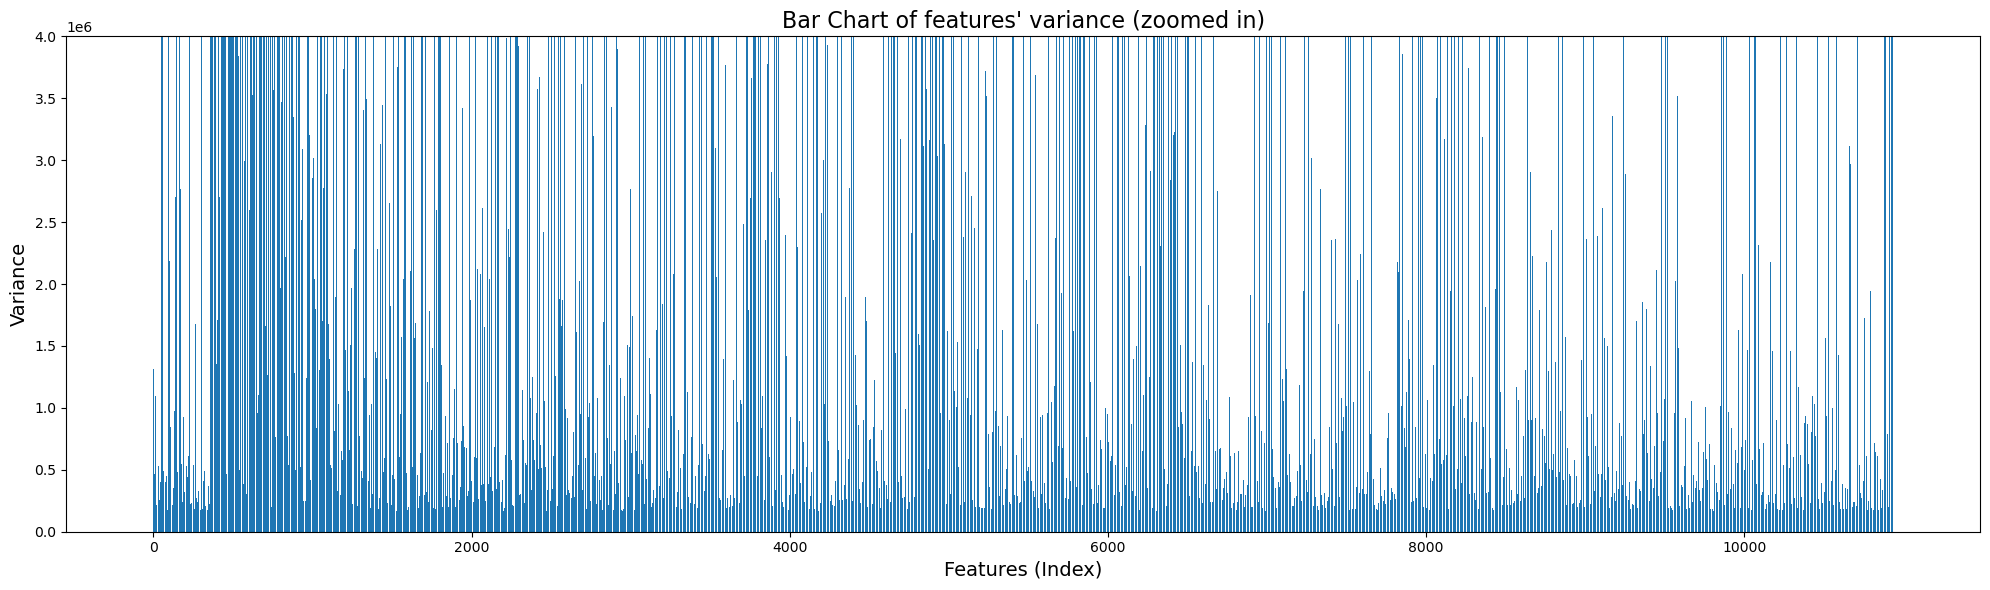

In [7]:
# Create a figure for the bar chart
plt.figure(figsize=(20, 6))

# Create the bar chart
plt.bar(range(len(variance_series)), variance_series.values)  # Use simple range instead of feature names

# Set labels and title
plt.xlabel("Features (Index)", fontsize=14)
plt.ylabel("Variance", fontsize=14)
plt.title("Bar Chart of features' variance (zoomed in)", fontsize=16)

# Set y axis limit
plt.ylim(0.0, 4000000) # Limit set to a "zoomed" value

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### Low variance filter application

In [8]:
# Exclude the last two columns ('Target' and 'Tissue') from the DataFrame
x = df.iloc[:, :-2].values

# Set y equal to the 'target' column
y = df['Target'].values

# Create a VarianceThreshold instance with an acceptable threshold
# An acceptable threshold should lead to (55-110) features count
sel = VarianceThreshold(threshold=(300000000)) #Reject features that have a lower than threshold variance

# Fit the VarianceThreshold to the data
sel.fit(x)

VarianceThreshold(threshold=300000000)

### Count the remaining features (target -> 55 - 110)

In [9]:
# Get the number of features that passed the threshold
remaining_features = sel.get_support().sum()

print(f"Number of features remaining: {remaining_features}")

Number of features remaining: 98


### Create a dataframe with the remaining features

In [10]:
# Get the indices of the features that passed the threshold
selected_features = sel.get_support()

# Create a new DataFrame with the selected features
x_selected = df.iloc[:, :-2].loc[:, selected_features]

# Add 'Target' and 'Tissue' columns back to this new DataFrame
df_selected = x_selected.copy()
df_selected['Target'] = df['Target']
df_selected['Tissue'] = df['Tissue']

# Assign the filtered DataFrame to df (rename it)
df = df_selected

df

,1553538_s_at,1553551_s_at,1553567_s_at,1553569_at,1553570_x_at,1553588_at,1555653_at,1556499_s_at,200003_s_at,200717_x_at,...,229659_s_at,AFFX-CreX-3_at,AFFX-CreX-5_at,AFFX-hum_alu_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,Target,Tissue
0,101939.7,79188.2,78548.9,79695.4,81373.3,82932.5,48695.9,6341.0,46503.7,58717.8,...,149.1,64127.8,59227.1,90722.5,30396.7,28371.7,85830.1,57084.9,0,Kidney
1,62075.5,53001.9,43285.7,50123.0,51560.9,49486.0,25368.1,19004.0,29198.2,43610.1,...,311.2,33593.3,28815.0,54776.9,16748.8,13581.2,53322.5,37139.5,0,Kidney
2,168655.1,32053.3,156871.0,104305.2,133398.5,154276.8,72650.6,15652.5,46739.0,79088.3,...,408.5,127790.6,108451.5,214034.7,64597.8,59311.2,203060.6,146422.6,0,Kidney
3,127382.8,106139.6,93669.1,107430.6,108189.8,141085.6,75596.0,43916.5,53118.7,54986.1,...,32.8,98447.0,90216.3,112892.8,58551.7,49073.6,119460.8,95682.3,0,Kidney
4,202406.5,89194.2,134037.2,96200.1,111069.8,137204.3,83284.8,35598.6,45815.7,67678.1,...,348.8,131028.8,118324.1,191001.4,54572.5,51049.1,178178.2,129533.2,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,82650.3,70763.6,67911.5,81602.7,78553.4,79633.4,29272.7,43172.3,60428.7,63033.7,...,33186.6,46628.6,42320.0,74103.6,22165.4,20442.0,65246.8,46710.2,1,Colon
542,107124.6,76868.8,83311.6,65950.8,73512.4,85249.7,20338.2,70094.8,54951.0,68575.8,...,2106.6,60248.2,46485.4,106527.6,21225.6,20067.2,80607.7,60204.9,1,Colon
543,80942.7,62972.8,50785.5,73531.2,74250.5,74794.9,33890.7,13787.4,52274.5,57842.0,...,11378.3,38609.1,32498.5,67663.2,19659.4,15774.8,56065.6,43347.8,1,Colon
544,118584.1,103234.3,78075.0,112106.0,108282.6,105504.0,52147.5,32273.1,58638.3,78335.6,...,25782.2,65646.3,57327.1,105755.9,34393.5,29137.7,89215.2,71290.1,1,Colon


### Export the low variance filtered dataset to .csv file

In [11]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Variance Filter\The colon-kidney low variance filtered dataset.csv"
df.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Variance Filter\The colon-kidney low variance filtered dataset.csv


### Transform outliers

In [12]:
# Function that tranforms outliers given a dataframe
def cap_outliers_iqr(df, threshold=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col in df_capped.columns and pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        else:
            print(f"Warning: Column '{col}' not found or is not numeric. Skipping.")
    return df_capped

In [13]:
# Transform outliers
df_capped = cap_outliers_iqr(df)
df_capped

,1553538_s_at,1553551_s_at,1553567_s_at,1553569_at,1553570_x_at,1553588_at,1555653_at,1556499_s_at,200003_s_at,200717_x_at,...,229659_s_at,AFFX-CreX-3_at,AFFX-CreX-5_at,AFFX-hum_alu_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,Target,Tissue
0,101939.7,79188.2,78548.9,79695.4,81373.3,82932.5,48695.9,6341.0,46503.7,58717.8,...,149.1,64127.8,59227.1,90722.5,30396.7,28371.7,85830.1,57084.9,0.0,Kidney
1,62075.5,53001.9,43285.7,50123.0,51560.9,49486.0,25368.1,19004.0,29198.2,43610.1,...,311.2,33593.3,28815.0,54776.9,16748.8,13581.2,53322.5,37139.5,0.0,Kidney
2,168655.1,32053.3,156871.0,104305.2,133398.5,154276.8,72650.6,15652.5,46739.0,79088.3,...,408.5,127790.6,108451.5,214034.7,64597.8,59311.2,203060.6,146422.6,0.0,Kidney
3,127382.8,106139.6,93669.1,107430.6,108189.8,141085.6,75596.0,43916.5,53118.7,54986.1,...,32.8,98447.0,90216.3,112892.8,58551.7,49073.6,119460.8,95682.3,0.0,Kidney
4,202406.5,89194.2,134037.2,96200.1,111069.8,137204.3,83284.8,35598.6,45815.7,67678.1,...,348.8,131028.8,118324.1,191001.4,54572.5,51049.1,178178.2,129533.2,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,82650.3,70763.6,67911.5,81602.7,78553.4,79633.4,29272.7,43172.3,60428.7,63033.7,...,33186.6,46628.6,42320.0,74103.6,22165.4,20442.0,65246.8,46710.2,1.0,Colon
542,107124.6,76868.8,83311.6,65950.8,73512.4,85249.7,20338.2,70094.8,54951.0,68575.8,...,2106.6,60248.2,46485.4,106527.6,21225.6,20067.2,80607.7,60204.9,1.0,Colon
543,80942.7,62972.8,50785.5,73531.2,74250.5,74794.9,33890.7,13787.4,52274.5,57842.0,...,11378.3,38609.1,32498.5,67663.2,19659.4,15774.8,56065.6,43347.8,1.0,Colon
544,118584.1,103234.3,78075.0,112106.0,108282.6,105504.0,52147.5,32273.1,58638.3,78335.6,...,25782.2,65646.3,57327.1,105755.9,34393.5,29137.7,89215.2,71290.1,1.0,Colon


### Check if "Transform Outliers" worked: Count how many elements are different between dataframes. If 0 nothing happened

In [14]:
# Compare element-wise and count differences
num_differences = (df != df_capped).sum().sum()

# Print results
if num_differences > 0:
    print(f"The tranformation of outliers worked. The amount of outliers that has been transformed is: {num_differences}")
else:
    print("No values transformed during outliers transformation phase")

The tranformation of outliers worked. The amount of outliers that has been transformed is: 1291


### Export the dataset to .csv file

In [15]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Variance Filter\The colon-kidney low variance filtered capped dataset.csv"
df_capped.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Variance Filter\The colon-kidney low variance filtered capped dataset.csv


### End time

In [16]:
# End time
end_time = time.time()

### Elapsed time

In [17]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for Low Variance Dataset: {elapsed_time:.2f} seconds")

Elapsed time for Low Variance Dataset: 27.84 seconds
